## Examples: Introduction to multiclass classification

#### In this notebook, we'll delve into the fundamentals of multiclass classification, address class imbalance, and apply logistic regression to the MBTI dataset.

### **Learning objectives**
#### By the end of this notebook, you should be able to:
#### - Understand and address class imbalance in the context of multiclass classification.
#### - Apply logistic regression techniques for multiclass classification problems.
#### - Gain practical experience with logistic regression on the MBTI dataset, navigating through its unique challenges

## Example 1: Resampling the email spam classification dataset

In [1]:
import ssl

# Set the path to the CA certificates bundle
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

# load a modified version of the Spambase dataset
df = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/Data/classification_sprint/unbalanced_email_spam_data.csv?raw=true')

In [3]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.0,1.63,0.0,0.00,0.0,0.00,0.0,0.0,0.00,...,0.000,0.000,0.000,2.695,0.000,0.000,2.315,12,44,1
1,0.00,0.0,0.00,0.0,0.26,0.0,0.26,0.0,0.0,0.00,...,0.462,0.084,0.084,0.378,0.000,1.051,13.820,104,1078,1
2,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.00,...,0.000,0.000,0.000,0.000,3.260,0.000,2.444,10,44,1
3,0.25,0.0,0.25,0.0,0.50,0.0,0.25,0.0,0.0,0.00,...,0.000,0.041,0.000,0.082,0.041,0.041,1.890,18,225,1
4,0.25,0.5,0.50,0.0,0.00,0.0,0.00,0.0,0.0,0.25,...,0.000,0.181,0.000,0.407,0.997,0.000,3.417,49,270,1


In [4]:
# separate minority and majority classes
not_spam = df[df['spam']==0]
spam = df[df['spam']==1]

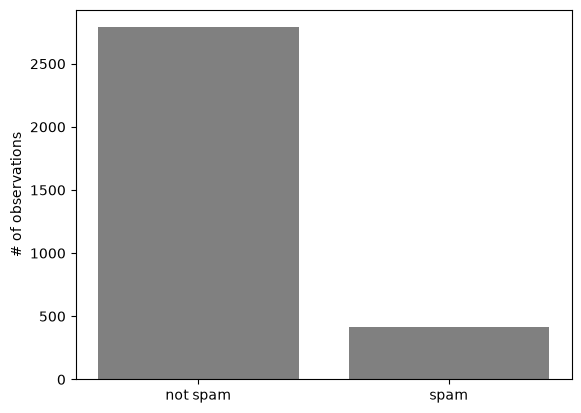

In [5]:
# get all possible labels
labels = df['spam'].unique()
heights = [len(spam), len(not_spam)]
plt.bar(labels, heights, color='grey')
plt.xticks(labels, ['spam', 'not spam'])
plt.ylabel('# of observations')
plt.show()

In [6]:
# percentage of non-spam emails in the dataset
len(not_spam)/(len(df))

0.8709778194314277

In [7]:
# As usual, we start by importing our modules
from sklearn.utils import resample

### Example 1.1: Approach 1 - Downsampling the majority class

In [8]:
# downsample majority
not_spam_downsampled = resample(
    not_spam,
    replace=False, # sample without replacement (no need to duplicate observations)
    n_samples=len(spam), # match number in minority class
    random_state=27
)

# Combine downsampled majority class with minority class
downsampled = pd.concat([not_spam_downsampled, spam])

# Check new class counts
downsampled['spam'].value_counts()

spam
0    413
1    413
Name: count, dtype: int64

In [9]:
labels

array([1, 0])

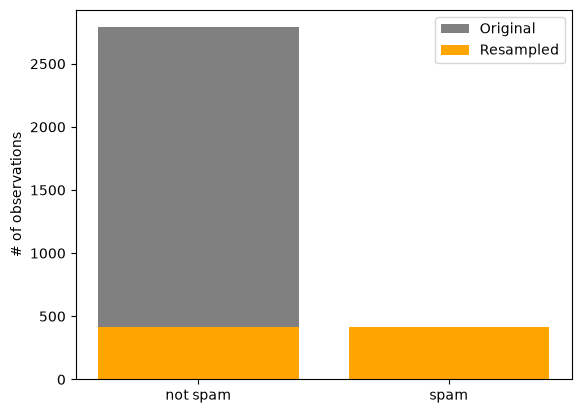

In [10]:
downsampled_heights = [len(downsampled[downsampled['spam']==0]), len(downsampled[downsampled['spam']==1])]

# Get all possible labels
labels = df['spam'].unique()
plt.bar(labels, heights, color='grey')
plt.bar(labels, downsampled_heights, color='orange')
plt.xticks(labels, ['spam', 'not spam'])
plt.ylabel('# of observations')
plt.legend(['Original', 'Resampled'])
plt.show()

### Example 1.2: Approach 2 - Upsampling the minority class

In [11]:
# upsampling minority
spam_upsampled = resample(
    spam,
    replace=True, # sample with replacement (we need to duplicate observations)
    n_samples=len(not_spam), # match number in minority class
    random_state=27
)

# combine upsampled minority class with majority class
upsampled = pd.concat([spam_upsampled, not_spam])

# check new class counts
upsampled['spam'].value_counts()

spam
1    2788
0    2788
Name: count, dtype: int64

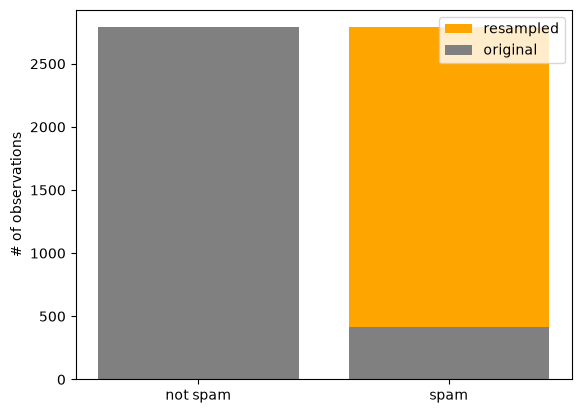

In [12]:
upsampled_heights = [
    len(upsampled[upsampled['spam']==0]), len(upsampled[upsampled['spam']==1])
]

# Get all possible labels
labels = df['spam'].unique()
plt.bar(labels, upsampled_heights, color='orange')
plt.bar(labels, heights, color='grey')
plt.xticks(labels, ['spam', 'not spam'])
plt.ylabel('# of observations')
plt.legend(['resampled', 'original'])
plt.show()

### Example 1.3: Approach 3 - Best of both (upsample minority class and downsample majority class

In [13]:
class_size = len(not_spam) // 2

In [14]:
majority_downsampled = resample(
    not_spam,
    replace=False,
    n_samples=class_size,
    random_state=42
)

In [15]:
minority_upsampled = resample(
    spam,
    replace=True,
    n_samples=class_size,
    random_state=42
)

In [16]:
balanced_df = pd.concat([majority_downsampled, minority_upsampled])

In [17]:
print(balanced_df['spam'].value_counts())

spam
0    1394
1    1394
Name: count, dtype: int64


## Example 2: Logistic Regression on the MBTI dataset

In [18]:
# imports
import numpy as np
import pandas as pd

from pylab import rcParams
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# customize our plotting settings
rcParams['figure.figsize'] = 10, 5
sns.set_style('whitegrid')

import sklearn
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report

import nltk

### Example 2.1: Getting and preprocessing the data

In [19]:
# Download the MBTI data
mbti = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/Data/classification_sprint/mbti.csv?raw=true')

In [20]:
mbti.head()

,Unnamed: 0,type,post
0,0,INFJ,urlweb
1,1,INFJ,urlweb
2,2,INFJ,enfp and intj moments urlweb sportscenter no...
3,3,INFJ,what has been the most lifechanging experience...
4,4,INFJ,urlweb urlweb on repeat for most of today


In [21]:
sum_mbti = mbti[['type', 'post']].groupby('type').count()

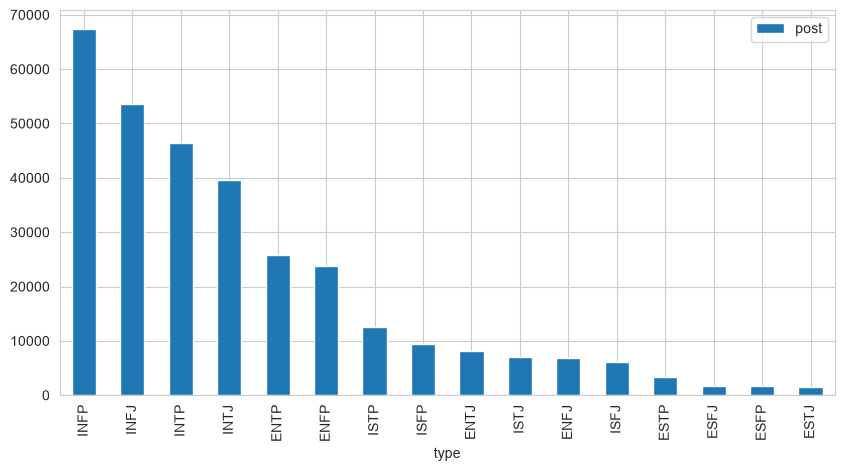

In [22]:
# Plot posts by personality type
sum_mbti.sort_values('post', ascending=False).plot(kind='bar')
plt.show()

### Example 2.3: Transforming text into numbers

#### 1. Features

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

In [27]:
# Let's use the count vectorizer with its default hyperparameters
vect = CountVectorizer()

mbti['post'] = mbti['post'].fillna('')

X_count = vect.fit_transform(mbti['post'].values.astype(str))

In [28]:
X_count.shape

(316548, 121556)

In [37]:
vect_20 = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=20,
    analyzer='word',
    ngram_range=(1, 3)
)

X_count = vect_20.fit_transform(mbti['post'].values.astype(str))

In [38]:
# uncomment and run this line to see feature names
vect_20.get_feature_names_out()

array(['dont', 'feel', 'good', 'im', 'ive', 'just', 'know', 'like', 'lot',
       'love', 'people', 'really', 'say', 'things', 'think', 'time',
       'type', 'urlweb', 'want', 'way'], dtype=object)

In [39]:
# Get the shape of our new predictive variables
X_count.shape

(316548, 20)

In [40]:
X = X_count.toarray()

#### 2. Response Variable

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit label encoder and return encoded labels
y = le.fit_transform(mbti['type'])

In [46]:
y

array([8, 8, 8, ..., 9, 9, 9], shape=(316548,))

In [48]:
# list of label encoder types to use for lookup
type_labels = list(le.classes_)

In [49]:
print(type_labels)

['ENFJ', 'ENFP', 'ENTJ', 'ENTP', 'ESFJ', 'ESFP', 'ESTJ', 'ESTP', 'INFJ', 'INFP', 'INTJ', 'INTP', 'ISFJ', 'ISFP', 'ISTJ', 'ISTP']


### Example 2.4: Training the logistic regression model on standard MBTI data

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

In [56]:
# Here 'ovr' indicates that we have selected our one-vs-rest strategy
logreg = OneVsRestClassifier(
    LogisticRegression()
)

In [57]:
logreg.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](16,)","[ 0, 1, 2,...,13,14,15]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegression(), LogisticRegression(), LogisticRegression(), LogisticRegression(), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,20
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'


### Example 2.5: Checking outcomes on the testing set

In [58]:
# Generate predictions
y_pred_test = logreg.predict(X_test)

In [59]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test, target_names=type_labels))

import warnings
warnings.filterwarnings('ignore')

              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00      1384
        ENFP       0.00      0.00      0.00      4791
        ENTJ       0.00      0.00      0.00      1643
        ENTP       0.00      0.00      0.00      5238
        ESFJ       0.00      0.00      0.00       337
        ESFP       0.00      0.00      0.00       319
        ESTJ       0.00      0.00      0.00       275
        ESTP       0.00      0.00      0.00       689
        INFJ       0.22      0.01      0.01     10777
        INFP       0.21      1.00      0.35     13475
        INTJ       0.00      0.00      0.00      8008
        INTP       0.00      0.00      0.00      9316
        ISFJ       0.00      0.00      0.00      1235
        ISFP       0.00      0.00      0.00      1880
        ISTJ       0.00      0.00      0.00      1462
        ISTP       0.00      0.00      0.00      2481

    accuracy                           0.21     63310
   macro avg       0.03   

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

### Example 3: Training the logistic regression moedl on balanced MBTI data

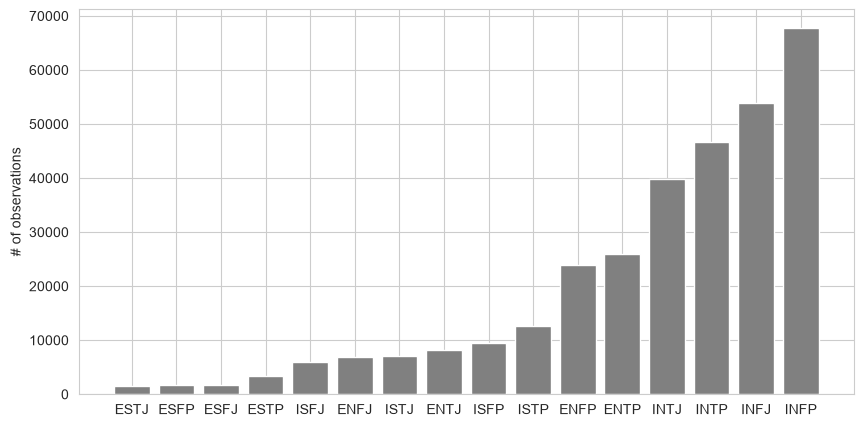

In [60]:
heights = [len(y[y == label]) for label in range(len(type_labels))]
bars = pd.DataFrame(
    zip(heights, le.transform(type_labels).T, type_labels),
    columns=['heights', 'labels', 'names'])
bars = bars.sort_values(by='heights', ascending=True)

plt.bar(range(len(bars)), bars['heights'], color='grey')
plt.xticks(range(len(bars)), bars['names'])
plt.ylabel('# of observations')
plt.show()

In [61]:
class_size = 30000

In [63]:
# before resampling, let's stitch our features and labels together
data = np.concatenate([X, y[:, np.newaxis]], axis=1)

In [64]:
bar_label_df = bars.set_index('labels')

In [65]:
resampled_classes = []

# For each label
for label in range(len(type_labels)):
    # Get num. of observations from this class
    label_size = bar_label_df.loc[label]['heights']

    # if label_size < class size the upsample, else downsample
    if label_size < class_size:
        # upsample
        label_data = data[data[:, -1] == label]
        label_resampled = resample(
            label_data,
            replace=True, # sample with replacement (we need to duplicate observations)
            n_samples=class_size, # number of desired samples
            random_state=27 # reproducible results
        )
    else:
        # Downsample
        label_data = data[data[:, -1] == label]
        label_resampled = resample(
            label_data,
            replace=False, # sample without replacement (no need for duplicate observations)
            n_samples=class_size, # number of desired samples
            random_state=27
        )

        resampled_classes.append(label_resampled)

In [67]:
resampled_data = np.concatenate(resampled_classes, axis=0)

In [68]:
resampled_data.shape

(120000, 21)

In [69]:
X_resampled = resampled_data[:,:-1]

In [70]:
y_resampled = resampled_data[:, -1]

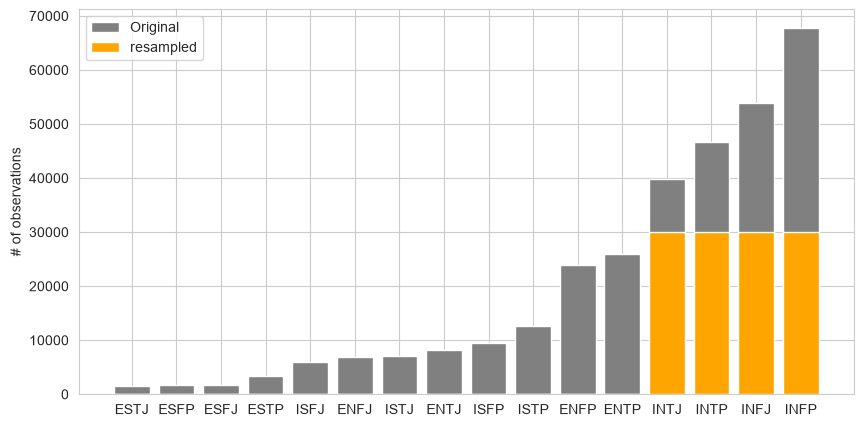

In [73]:
heights = [len(y_resampled[y_resampled == label]) for label in range(len(type_labels))]
bars_resampled = pd.DataFrame(
    zip(heights, le.transform(type_labels).T, type_labels),
    columns=['heights', 'labels', 'names']
)
bars_resampled = bars_resampled.sort_values(by='heights', ascending=True)

plt.bar(range(len(bars)), bars['heights'], color='grey')
plt.bar(range(len(bars_resampled)), bars_resampled['heights'], color='orange')
plt.xticks(range(len(bars)), bars['names'])
plt.ylabel('# of observations')
plt.legend(['Original', 'resampled'])
plt.show()

#### Train test split with balanced data

In [74]:
# Setting up the train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=27
)

#### Training the model

In [75]:
# Training the logistic regression model on our rebalanced data
logreg = OneVsRestClassifier(
    LogisticRegression()
)

In [76]:
logreg.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](4,)","[ 8, 9,10,11]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegression(), LogisticRegression(), LogisticRegression(), LogisticRegression()]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,20
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'


#### Checking outcomes on the testing set

In [77]:
# Generate predictions
y_pred_test = logreg.predict(X_test)

In [87]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix

labels = np.unique(y_test)

print(classification_report(
    y_test,
    y_pred_test,
    labels=labels,
    target_names=le.inverse_transform(labels)
))

              precision    recall  f1-score   support

        INFJ       0.26      0.13      0.17      5948
        INFP       0.30      0.25      0.27      6054
        INTJ       0.27      0.52      0.35      5990
        INTP       0.27      0.20      0.23      6008

    accuracy                           0.27     24000
   macro avg       0.27      0.27      0.26     24000
weighted avg       0.27      0.27      0.26     24000



In [84]:
np.unique(y_test)

array([ 8,  9, 10, 11])

In [85]:
np.unique(y_pred_test)

array([ 8,  9, 10, 11])

In [82]:
type_labels

['ENFJ',
 'ENFP',
 'ENTJ',
 'ENTP',
 'ESFJ',
 'ESFP',
 'ESTJ',
 'ESTP',
 'INFJ',
 'INFP',
 'INTJ',
 'INTP',
 'ISFJ',
 'ISFP',
 'ISTJ',
 'ISTP']